In [1]:
import os
import uuid
import rasterio
import datacube
from datacube.index.hl import Doc2Dataset
from datetime import datetime, timezone

# ==============================================================
# 1. CẤU HÌNH TRỎ S3 VỀ MINIO NỘI BỘ
# ==============================================================
os.environ["AWS_ACCESS_KEY_ID"] = "minioadmin"
os.environ["AWS_SECRET_ACCESS_KEY"] = "minioadmin123"
os.environ["AWS_S3_ENDPOINT"] = "minio:9000"  # Sửa thành localhost:9000 nếu chạy ngoài container
os.environ["AWS_HTTPS"] = "NO"
os.environ["AWS_VIRTUAL_HOSTING"] = "FALSE"

def process_and_index_tif(year):
    """Hàm tự động quét cấu trúc file TIF và nạp vào ODC theo năm"""
    print(f"\n{'='*50}")
    print(f"🚀 BẮT ĐẦU XỬ LÝ DỮ LIỆU NĂM {year}")
    print(f"{'='*50}")

    # Động hóa đường dẫn theo năm
    tif_path = f"s3://odc-data/CLIPPED_IMG_CAN_THO/{year}/{year}.tif"
    dataset_uri = f"s3://odc-data/CLIPPED_IMG_CAN_THO/{year}/dataset.yaml"

    # Khởi tạo kết nối ODC
    try:
        dc = datacube.Datacube(app=f"inject_custom_{year}")
        resolver = Doc2Dataset(dc.index)
    except Exception as e:
        print(f"❌ Lỗi kết nối ODC: {e}")
        return

    # ==============================================================
    # 2. ĐỌC THÔNG SỐ TỰ ĐỘNG TỪ RASTERIO
    # ==============================================================
    print(f"1️⃣ Đang quét thông tin từ: {tif_path} ...")
    try:
        with rasterio.open(tif_path) as src:
            extracted_crs = src.crs.to_string()
            extracted_shape = list(src.shape)
            extracted_transform = list(src.transform)[:6]

            print(f"   - Hệ tọa độ (CRS): {extracted_crs}")
            print(f"   - Kích thước (Shape): {extracted_shape}")
            print(f"   - Tổng dải băng (Bands): {src.count}")
    except Exception as e:
        print(f"❌ Lỗi khi đọc file TIF năm {year}. Vui lòng kiểm tra lại đường dẫn MinIO: {e}")
        return

    # ==============================================================
    # 3. TẠO CẤU TRÚC EO3 VÀ NẠP VÀO DATABASE
    # ==============================================================
    print(f"2️⃣ Đang biên dịch siêu dữ liệu và nạp vào PostGIS ...")

    # Tạo ID cố định cho file theo từng năm (Tránh sinh ID ngẫu nhiên mỗi lần chạy)
    dataset_id = str(uuid.uuid5(uuid.NAMESPACE_DNS, f"custom_{year}_tif_cantho"))

    custom_dataset_doc = {
        "$schema": "https://schemas.opendatacube.org/dataset",
        "id": dataset_id,
        "product": {
            "name": "s2_l2a_cantho" 
        },
        "crs": extracted_crs,
        "grids": {
            "default": {
                "shape": extracted_shape,
                "transform": extracted_transform + [0, 0, 1]
            }
        },
        "properties": {
            # Tự động gán mốc thời gian theo biến year
            "datetime": f"{year}-01-01T00:00:00Z", 
            "odc:processing_datetime": datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
            "odc:processing_level": "l2a",
            "eo:platform": "sentinel-2",
            "eo:instrument": "msi"
        },
        "measurements": {
            # ĐÃ ĐẢO LẠI LAYER: NIR=1, RED=2 để tính toán NDVI không bị đỏ ảnh
            "red": {"path": tif_path, "layer": 2}, 
            "nir": {"path": tif_path, "layer": 1},
            
            # Gán bừa layer 1 cho SCL để qua vòng Validation của Database
            # Nhớ: Khi gọi dc.load() vẽ biểu đồ thì KHÔNG load dải SCL này ra.
            "SCL": {"path": tif_path, "layer": 1} 
        },
        "lineage": {}
    }

    # Biên dịch và nạp
    odc_dataset, error = resolver(custom_dataset_doc, uri=dataset_uri)

    if error:
        print(f"❌ Lỗi Validation năm {year}: {error}")
    else:
        try:
            dc.index.datasets.add(odc_dataset)
            print(f"🎉 THÀNH CÔNG! Đã nạp file {year}.tif vào CSDL.")
            print(f"   - ID cấp phát: {dataset_id}")
        except Exception as e:
             print(f"❌ Lỗi ghi vào Database năm {year} (Có thể đã tồn tại): {e}")

# ==============================================================
# KHỐI THỰC THI CHÍNH
# ==============================================================
if __name__ == "__main__":
    # Dễ dàng thêm bớt các năm bạn muốn nạp vào mảng này
    years_to_process = ["2021", "2022", "2023"]
    
    for y in years_to_process:
        process_and_index_tif(y)
        
    print("\n✅ Đã hoàn thành toàn bộ tiến trình.")
    print("💡 Đừng quên chạy lệnh 'docker compose ... explorer-index' để giao diện Web cập nhật ranh giới của các năm nhé!")


🚀 BẮT ĐẦU XỬ LÝ DỮ LIỆU NĂM 2021
1️⃣ Đang quét thông tin từ: s3://odc-data/CLIPPED_IMG_CAN_THO/2021/2021.tif ...
   - Hệ tọa độ (CRS): EPSG:4326
   - Kích thước (Shape): [15042, 22938]
   - Tổng dải băng (Bands): 2
2️⃣ Đang biên dịch siêu dữ liệu và nạp vào PostGIS ...


/usr/local/lib/python3.12/site-packages/antimeridian/_implementation.py:442: FixWindingWarning: The exterior ring of this shape is wound clockwise. Since this is a common error in real-world geometries, this package is reversing the exterior coordinates of the input shape before running its algorithm. If you know that your input shape is correct (i.e. if your data encompasses both poles), pass `fix_winding=False`.
  FixWindingWarning.warn()


🎉 THÀNH CÔNG! Đã nạp file 2021.tif vào CSDL.
   - ID cấp phát: b3abe02e-d112-50bd-8039-b95f5238c7bd

🚀 BẮT ĐẦU XỬ LÝ DỮ LIỆU NĂM 2022
1️⃣ Đang quét thông tin từ: s3://odc-data/CLIPPED_IMG_CAN_THO/2022/2022.tif ...
   - Hệ tọa độ (CRS): EPSG:4326
   - Kích thước (Shape): [15042, 22938]
   - Tổng dải băng (Bands): 2
2️⃣ Đang biên dịch siêu dữ liệu và nạp vào PostGIS ...
🎉 THÀNH CÔNG! Đã nạp file 2022.tif vào CSDL.
   - ID cấp phát: 208833ef-3c5d-54cf-ad92-c887e9407104

🚀 BẮT ĐẦU XỬ LÝ DỮ LIỆU NĂM 2023
1️⃣ Đang quét thông tin từ: s3://odc-data/CLIPPED_IMG_CAN_THO/2023/2023.tif ...
   - Hệ tọa độ (CRS): EPSG:4326
   - Kích thước (Shape): [15042, 22938]
   - Tổng dải băng (Bands): 2
2️⃣ Đang biên dịch siêu dữ liệu và nạp vào PostGIS ...
🎉 THÀNH CÔNG! Đã nạp file 2023.tif vào CSDL.
   - ID cấp phát: a0b258c2-8c4b-52e7-a3ce-05341d56bcab

✅ Đã hoàn thành toàn bộ tiến trình.
💡 Đừng quên chạy lệnh 'docker compose ... explorer-index' để giao diện Web cập nhật ranh giới của các năm nhé!


Đang quét khối dữ liệu không gian - thời gian...
✅ Tìm thấy 3 bức ảnh. Đang tiến hành vẽ biểu đồ...


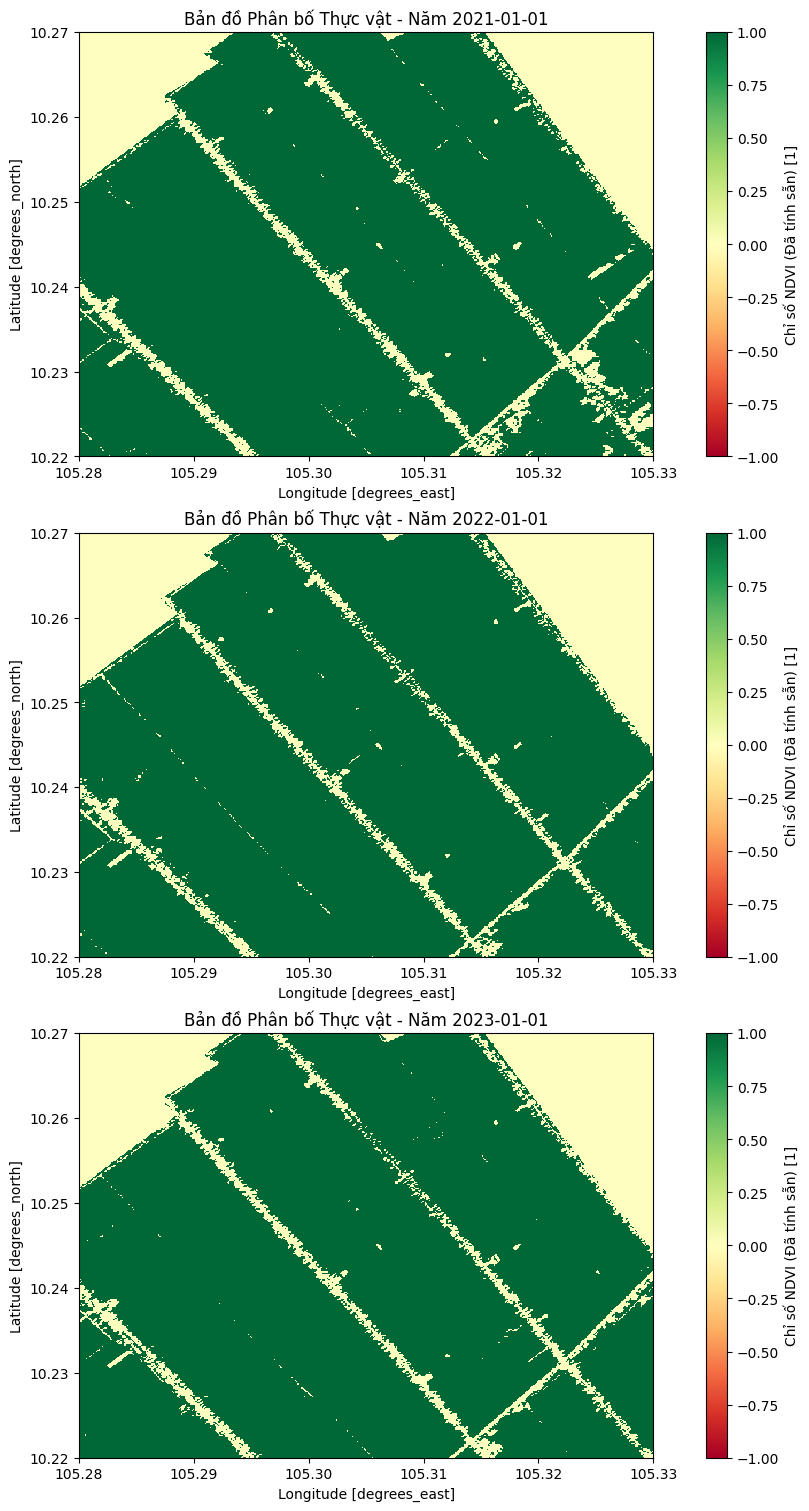

In [10]:
import os
import datacube
import matplotlib.pyplot as plt

# ==============================================================
# CẤU HÌNH KẾT NỐI MINIO NỘI BỘ 
# ==============================================================
for key in list(os.environ.keys()):
    if key.startswith("AWS_") or key.startswith("S3_") or key.startswith("GDAL_"):
        del os.environ[key]

os.environ["AWS_ACCESS_KEY_ID"] = "minioadmin"
os.environ["AWS_SECRET_ACCESS_KEY"] = "minioadmin123"
os.environ["AWS_S3_ENDPOINT"] = "minio:9000"  # Hoặc localhost:9000
os.environ["AWS_REGION"] = "local"
os.environ["AWS_HTTPS"] = "NO"
os.environ["AWS_VIRTUAL_HOSTING"] = "FALSE"
os.environ["S3_USE_HTTPS"] = "0"
os.environ["GDAL_DISABLE_READDIR_ON_OPEN"] = "EMPTY_DIR"
# ==============================================================

dc = datacube.Datacube(app="ndvi_precalculated_display")

query = {
    'lon': (105.28, 105.33),
    'lat': (10.22, 10.27),
    'time': ('2021-01-01', '2026-12-31') 
}

print("Đang quét khối dữ liệu không gian - thời gian...")

# Vẫn gọi 'nir' vì trong CSDL ta đã gán Layer 1 vào tên 'nir'
ds = dc.load(
    product='s2_l2a_cantho',
    measurements=['nir'], 
    output_crs='EPSG:4326',
    resolution=(-0.0001, 0.0001), 
    **query
)

if 'time' in ds.dims:
    num_scenes = ds.time.size
    print(f"✅ Tìm thấy {num_scenes} bức ảnh. Đang tiến hành vẽ biểu đồ...")

    fig, axes = plt.subplots(num_scenes, 1, figsize=(8, 5 * num_scenes), constrained_layout=True)
    
    if num_scenes == 1:
        axes = [axes]

    for i in range(num_scenes):
        scene = ds.isel(time=i)
        date_str = str(scene.time.values)[:10]
        
        # BỎ BƯỚC TÍNH TOÁN NDVI BẰNG TOÁN HỌC
        # Lấy trực tiếp dữ liệu từ Layer 1 (đang được gán tên là nir)
        ndvi_ready = scene.nir.astype(float)
        
        # Vẽ biểu đồ với dải màu thực vật chuẩn
        ndvi_ready.plot(
            ax=axes[i],
            cmap='RdYlGn', 
            vmin=-1.00, 
            vmax=1.00,
            add_colorbar=True,
            cbar_kwargs={'label': 'Chỉ số NDVI (Đã tính sẵn) [1]'}
        )
        
        axes[i].set_title(f'Bản đồ Phân bố Thực vật - Năm {date_str}')
        axes[i].set_xlabel('Longitude [degrees_east]')
        axes[i].set_ylabel('Latitude [degrees_north]')

    plt.show()

else:
    print("❌ Không tìm thấy dữ liệu nào.")